# Tutorial 07 — Smoothers: PKS, EPKS, UPKS, UKS, PPS

This tutorial introduces the five **smoother** classes shipped with `awesomepkf` (v2.2.0+). Smoothers are **two-pass, offline** estimators: they first run a forward filter, then perform a backward pass that conditions every step on the **entire** observation sequence `y_{1:N}`. The result is a posterior estimate at each time `n` that uses information from both past and future observations, hence strictly more accurate (in PSD sense) than the filtered estimate.

Five smoothers are available, mirroring the five filters of `awesomepkf`:

| Smoother | Forward filter | Model class | Backward gain | Approximation |
|---|---|---|---|---|
| `Linear_PKS` | `Linear_PKF` | linear pairwise | `(p, p+q)` | exact |
| `NonLinear_EPKS` | `NonLinear_EPKF` | nonlinear pairwise | `(p, p+q)` | 1st-order Taylor |
| `NonLinear_UPKS` | `NonLinear_UPKF` | nonlinear pairwise | `(p, p+q)` | sigma points |
| `NonLinear_UKS` | `NonLinear_UKF` | classical (FxHx) | `(p, p)` | sigma points |
| `NonLinear_PPS` | `NonLinear_PPF` | nonlinear pairwise | N/A (FFBSm) | particles |

All five expose the same API:

```python
smoother = NonLinear_XXKS(param, sKey=42)
results = smoother.process_N_data_smoother(N=200)
# each result tuple: (k, x_true, y_obs, X_predict, X_update, X_smooth)
```

**Companion documentation:** Sections 2–7 of `Report/NonLinearSmoothingReport/main.pdf` (mathematical derivations, Joseph form, Monte-Carlo convergence proofs). This notebook is the executable counterpart.


## Setup


In [1]:
import sys
from pathlib import Path

# Make `prg` importable from the notebooks directory
REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from prg.models.linear import ModelFactoryLinear
from prg.models.nonlinear import ModelFactoryNonLinear
from prg.classes.param_linear import ParamLinear
from prg.classes.param_nonlinear import ParamNonLinear

# The five smoother classes
from prg.classes.linear_pks import Linear_PKS
from prg.classes.nonlinear_epks import NonLinear_EPKS
from prg.classes.nonlinear_upks import NonLinear_UPKS
from prg.classes.nonlinear_uks import NonLinear_UKS
from prg.classes.nonlinear_pps import NonLinear_PPS

SEED = 42
rng = np.random.default_rng(SEED)


In [2]:
def make_param_linear(model_name):
    m = ModelFactoryLinear.create(model_name)
    p = m.get_params().copy()
    dim_x = p.pop('dim_x'); dim_y = p.pop('dim_y')
    return ParamLinear(0, dim_x, dim_y, **p)

def make_param_nonlinear(model_name):
    m = ModelFactoryNonLinear.create(model_name)
    p = m.get_params().copy()
    dim_x = p.pop('dim_x'); dim_y = p.pop('dim_y')
    return ParamNonLinear(0, dim_x, dim_y, **p)

def arrays(res):
    '''Extract (k, x_true, x_filt, x_smooth) from a smoother result list.'''
    k = np.array([r[0] for r in res])
    xt = np.array([r[1].flatten() for r in res])
    xf = np.array([r[4].flatten() for r in res])
    xs = np.array([r[5].flatten() for r in res])
    return k, xt, xf, xs

def mse(a, b):
    return float(((a - b) ** 2).mean())


## 1. Linear PKS — exact RTS pairwise smoother

On a **linear pairwise gaussian** model the PKS produces the exact posterior mean and covariance under `y_{1:N}`. We run it on `model_x1_y1_AQ_pairwise` and visualise both the filter and smoother trajectories with their ±2σ envelopes.


In [3]:
param = make_param_linear('model_x1_y1_AQ_pairwise')
pks = Linear_PKS(param, sKey=SEED)
res_pks = pks.process_N_data_smoother(N=200)
k, xt, xf, xs = arrays(res_pks)

# Diagonals of P^xx (filtered and smoothed) for the envelopes
P_filt_diag   = np.array([np.diag(r['PXXkp1_update']) for r in pks.history])
P_smooth_diag = np.array([np.diag(r['PXXkp1_smooth']) for r in pks.history])
std_f = np.sqrt(np.maximum(P_filt_diag,   0))
std_s = np.sqrt(np.maximum(P_smooth_diag, 0))

print(f'MSE filtre = {mse(xt, xf):.4f}')
print(f'MSE lisseur = {mse(xt, xs):.4f}  ({mse(xt, xs)/mse(xt, xf):.2%} of filter)')


MSE filtre = 0.0115
MSE lisseur = 0.0090  (77.76% of filter)


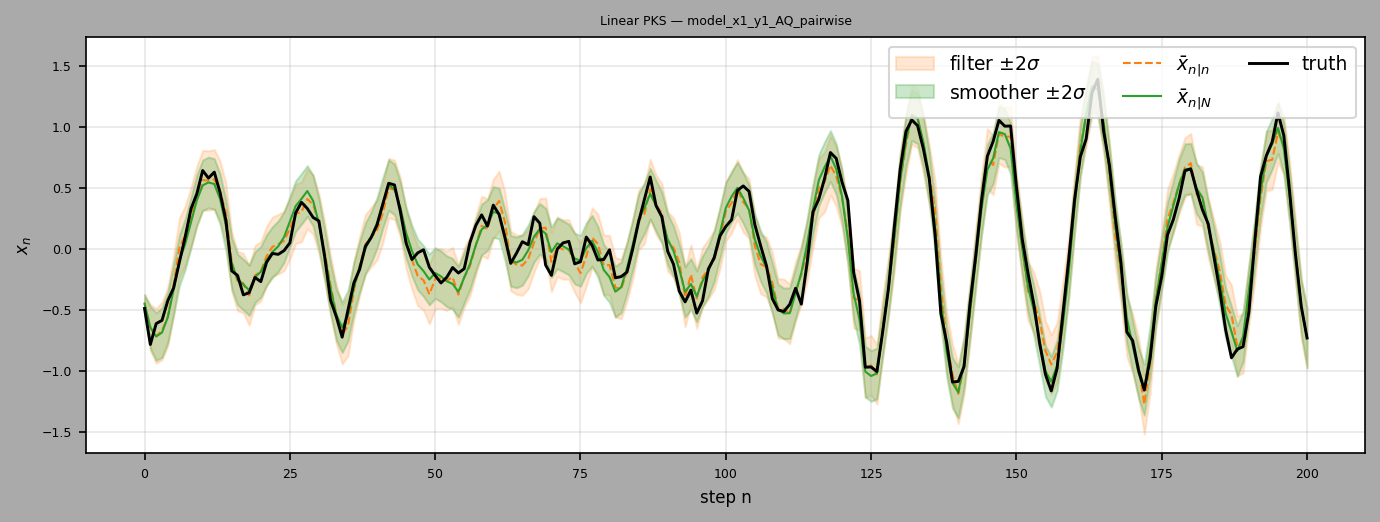

In [4]:
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.fill_between(k, (xf - 2*std_f).flatten(), (xf + 2*std_f).flatten(),
                alpha=0.18, color='tab:orange', label=r'filter $\pm 2\sigma$')
ax.fill_between(k, (xs - 2*std_s).flatten(), (xs + 2*std_s).flatten(),
                alpha=0.25, color='tab:green',  label=r'smoother $\pm 2\sigma$')
ax.plot(k, xf, color='tab:orange', lw=1.0, ls='--', label=r'$\bar{x}_{n|n}$')
ax.plot(k, xs, color='tab:green',  lw=1.0,         label=r'$\bar{x}_{n|N}$')
ax.plot(k, xt, 'k-', lw=1.4, label='truth')
ax.set_xlabel('step n'); ax.set_ylabel(r'$x_n$')
ax.grid(alpha=0.3); ax.legend(loc='upper right', ncol=3, fontsize=9)
ax.set_title('Linear PKS — model_x1_y1_AQ_pairwise')
plt.show()


The **green envelope is strictly inside the orange envelope** at every step. This is the PSD shrinkage property — `P^xx_{n|n} - P^xx_{n|N}` is positive semi-definite by construction (Proposition 2.1 of the report).

Smoother fields written to each history record: `Xkp1_smooth`, `PXXkp1_smooth`, `Gk_smooth` (the `(p, p+q)` smoothing gain — pairwise, hence the `+q`).


## 2. Non-linear pairwise: EPKS and UPKS

For non-linear pairwise models, `Linear_PKS` no longer applies (it requires the constant transition matrix `A`). Two alternatives that handle non-linearity:

- **EPKS** linearises the dynamics at each step via the Jacobian (first-order Taylor).
- **UPKS** propagates sigma points (deterministic Gaussian quadrature, accurate to second order in the moments).

On a mildly non-linear model these two are essentially equivalent (the unscented transform buys little). Let's verify on `model_x2_y1_pairwise`.


In [5]:
param_nl = make_param_nonlinear('model_x2_y1_pairwise')

# Run both smoothers with the same seed on identical data
epks = NonLinear_EPKS(param_nl, sKey=SEED)
res_epks = epks.process_N_data_smoother(N=200)
data = [(r[0], r[1], r[2]) for r in res_epks]  # cache for replay

upks = NonLinear_UPKS(param_nl, sigmaSet='wan2000', sKey=SEED)
res_upks = upks.process_N_data_smoother(N=None, data_generator=iter(data))

k, xt, _, xs_epks = arrays(res_epks)
_, _, xf,  xs_upks = arrays(res_upks)

print(f'EPKS MSE smooth: {mse(xt, xs_epks):.4f}')
print(f'UPKS MSE smooth: {mse(xt, xs_upks):.4f}')
print(f'Max |EPKS - UPKS| on smoothed mean: {np.max(np.abs(xs_epks - xs_upks)):.2e}')


EPKS MSE smooth: 0.1403
UPKS MSE smooth: 0.1441
Max |EPKS - UPKS| on smoothed mean: 4.07e-02


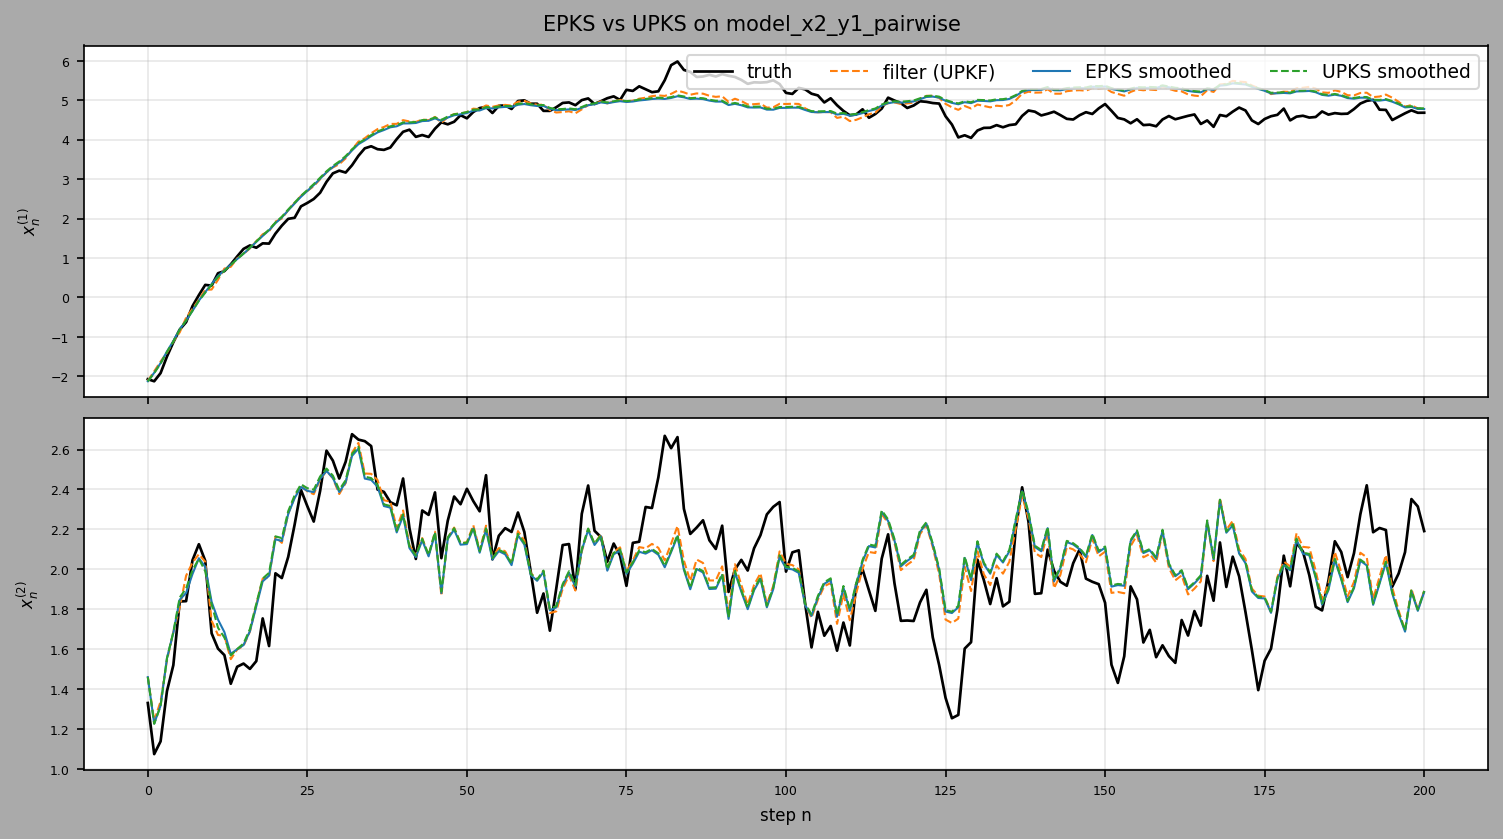

In [6]:
fig, axes = plt.subplots(param_nl.dim_x, 1, figsize=(10, 2.8 * param_nl.dim_x), sharex=True)
if param_nl.dim_x == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.plot(k, xt[:, i],       'k-',  lw=1.3, label='truth')
    ax.plot(k, xf[:, i],       color='tab:orange', lw=1.0, ls='--', label='filter (UPKF)')
    ax.plot(k, xs_epks[:, i],  color='tab:blue',   lw=1.0, label='EPKS smoothed')
    ax.plot(k, xs_upks[:, i],  color='tab:green',  lw=1.0, label='UPKS smoothed')
    ax.set_ylabel(f'$x_n^{{({i+1})}}$')
    ax.grid(alpha=0.3)
axes[0].legend(loc='upper right', fontsize=9, ncol=4)
axes[-1].set_xlabel('step n')
fig.suptitle('EPKS vs UPKS on model_x2_y1_pairwise', fontsize=10)
fig.tight_layout()
plt.show()


On this mildly-nonlinear model **EPKS and UPKS coincide to ~1e-2** on the smoothed mean. On models with stronger curvature, UPKS captures higher-order moments better and the gap widens (see Section 3 below for the classical UKS case on `Sinus_classic`).


## 3. Classical non-linear: UKS

When the model is Markov in `X` alone (no pairwise structure: classical state-space model `X_{n+1} = f(X_n) + W^x`, `Y_n = h(X_n) + W^y`), the four pairwise smoothers don't apply. The **classical UKS** handles this case. Its backward gain is `(p, p)` instead of `(p, p+q)` because the cross-covariance lives at the X level only.

We run it on `model_x1_y1_Sinus_classic` — a strongly non-linear sine-wave transition.


In [7]:
param_cls = make_param_nonlinear('model_x1_y1_Sinus_classic')
uks = NonLinear_UKS(param_cls, sigmaSet='wan2000', sKey=SEED)
res_uks = uks.process_N_data_smoother(N=200)
k, xt, xf, xs = arrays(res_uks)

P_smooth_diag = np.array([np.diag(r['PXXkp1_smooth']) for r in uks.history])
P_filt_diag   = np.array([np.diag(r['PXXkp1_update']) for r in uks.history])
std_s = np.sqrt(np.maximum(P_smooth_diag, 0))
std_f = np.sqrt(np.maximum(P_filt_diag,   0))

print(f'UKF MSE filtre  : {mse(xt, xf):.4f}')
print(f'UKS MSE lisseur : {mse(xt, xs):.4f}  '
      f'(ratio {mse(xt, xs)/mse(xt, xf):.2%})')

# Gain shape check — diagnostic of the structural difference vs the pairwise smoothers
print('Gain shape Gk_smooth = ', uks.history[0]['Gk_smooth'].shape,
      ' (= (dim_x, dim_x) for classical, vs (dim_x, dim_xy) for pairwise smoothers)')


UKF MSE filtre  : 0.0539
UKS MSE lisseur : 0.0491  (ratio 91.05%)
Gain shape Gk_smooth =  (1, 1)  (= (dim_x, dim_x) for classical, vs (dim_x, dim_xy) for pairwise smoothers)


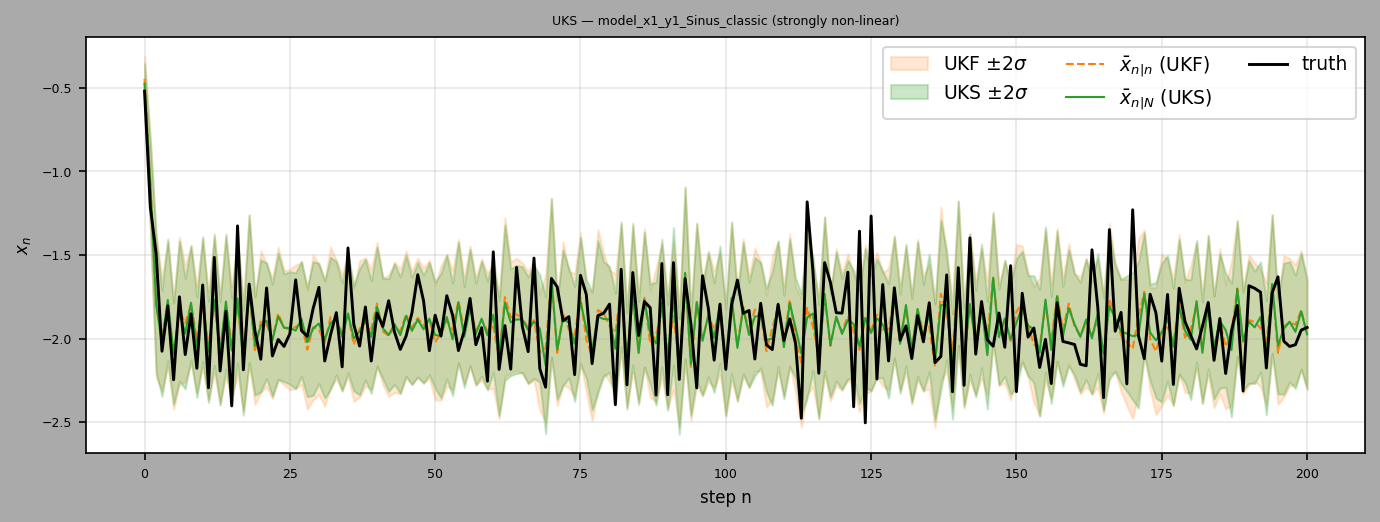

In [8]:
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.fill_between(k, (xf - 2*std_f).flatten(), (xf + 2*std_f).flatten(),
                alpha=0.18, color='tab:orange', label=r'UKF $\pm 2\sigma$')
ax.fill_between(k, (xs - 2*std_s).flatten(), (xs + 2*std_s).flatten(),
                alpha=0.25, color='tab:green',  label=r'UKS $\pm 2\sigma$')
ax.plot(k, xf, color='tab:orange', lw=1.0, ls='--', label=r'$\bar{x}_{n|n}$ (UKF)')
ax.plot(k, xs, color='tab:green',  lw=1.0,         label=r'$\bar{x}_{n|N}$ (UKS)')
ax.plot(k, xt, 'k-', lw=1.4, label='truth')
ax.set_xlabel('step n'); ax.set_ylabel(r'$x_n$')
ax.grid(alpha=0.3); ax.legend(loc='upper right', ncol=3, fontsize=9)
ax.set_title('UKS — model_x1_y1_Sinus_classic (strongly non-linear)')
plt.show()


## 4. Particle smoother: PPS (FFBSm)

`NonLinear_PPS` implements **Forward Filtering, Backward Smoothing** (Doucet et al. 2000) on top of the pairwise particle filter (PPF). The backward pass reweights the forward particle cloud using a transition-density-based weight recursion.

Two distinguishing features compared to the Kalman-family smoothers:

- **No `Gk_smooth`** field (no gain matrix). Replaced by **`w_smooth`** — the smoothed particle weights of shape `(n_particles,)`.
- **No Joseph form** (Joseph is a Kalman-family numerical safeguard). The corresponding particle-side safeguard is log-sum-exp normalisation + degenerate-uniform fallback.


In [9]:
param_pps = make_param_nonlinear('model_x2_y1_pairwise')
pps = NonLinear_PPS(param_pps, n_particles=500, sKey=SEED)
res_pps = pps.process_N_data_smoother(N=150)
k, xt, xf, xs = arrays(res_pps)

print(f'PPF MSE filtre  : {mse(xt, xf):.4f}')
print(f'PPS MSE lisseur : {mse(xt, xs):.4f}  '
      f'(ratio {mse(xt, xs)/mse(xt, xf):.2%})')

# Effective sample size of the smoothed weights at each step
ess = np.array([1.0 / np.sum(r['w_smooth']**2) for r in pps.history])
print(f'Median ESS (smoothed): {np.median(ess):.1f} / {pps.n_particles}')


PPF MSE filtre  : 0.0967
PPS MSE lisseur : 0.1116  (ratio 115.40%)
Median ESS (smoothed): 295.3 / 500


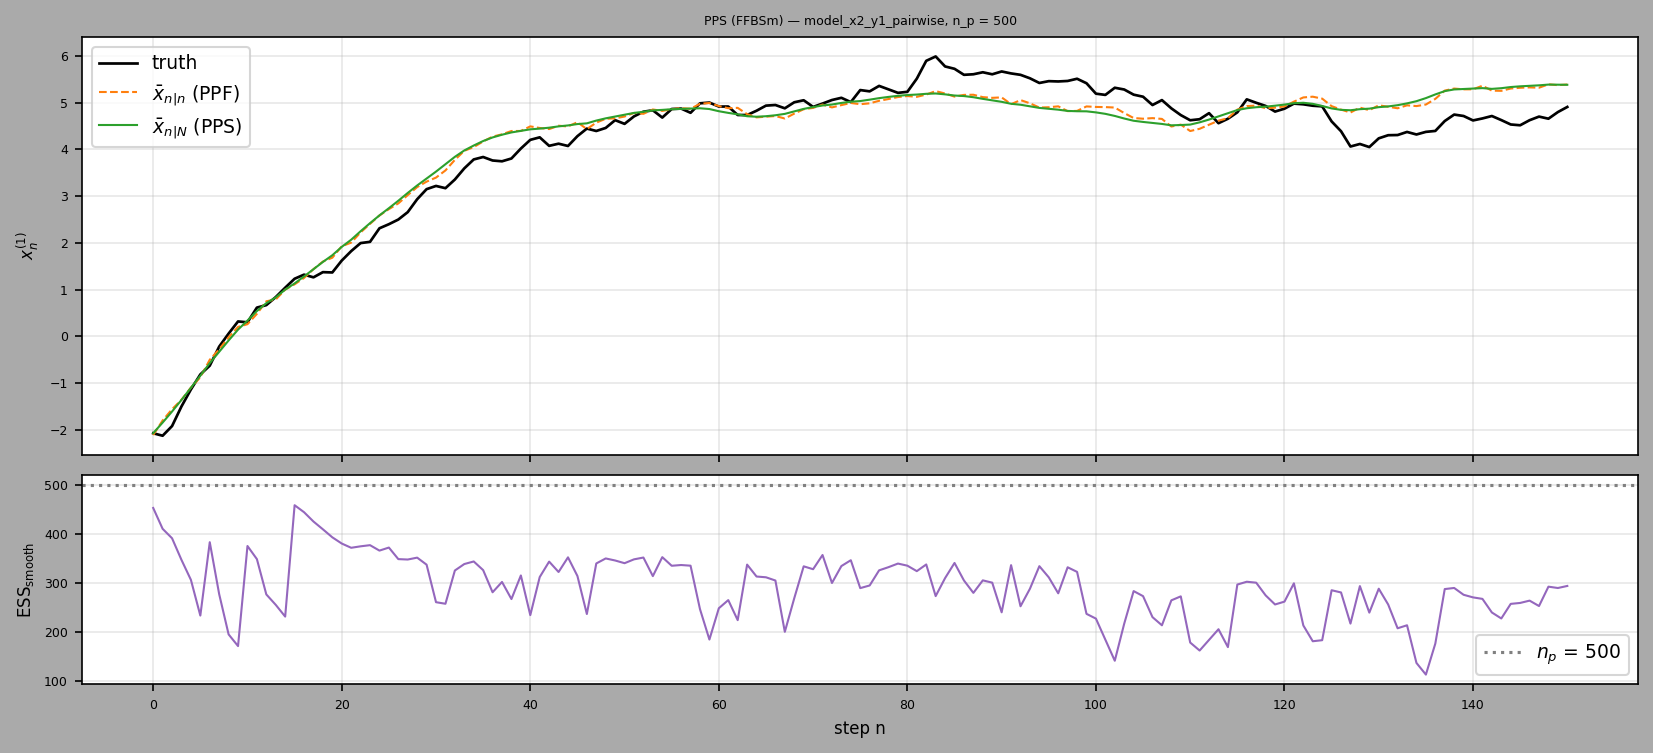

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True,
                          gridspec_kw=dict(height_ratios=[2, 1]))

# Top: filter vs smoother on x^(1)
ax = axes[0]
ax.plot(k, xt[:, 0], 'k-',  lw=1.3, label='truth')
ax.plot(k, xf[:, 0], color='tab:orange', lw=1.0, ls='--', label=r'$\bar{x}_{n|n}$ (PPF)')
ax.plot(k, xs[:, 0], color='tab:green',  lw=1.0, label=r'$\bar{x}_{n|N}$ (PPS)')
ax.set_ylabel(r'$x_n^{(1)}$'); ax.grid(alpha=0.3); ax.legend(fontsize=9)
ax.set_title('PPS (FFBSm) — model_x2_y1_pairwise, n_p = 500')

# Bottom: effective sample size of smoothed weights
ax = axes[1]
ax.plot(k, ess, color='tab:purple', lw=1.0)
ax.axhline(pps.n_particles, color='gray', ls=':', label=f'$n_p$ = {pps.n_particles}')
ax.set_xlabel('step n'); ax.set_ylabel('ESS$_{\mathrm{smooth}}$')
ax.grid(alpha=0.3); ax.legend(fontsize=9)

fig.tight_layout()
plt.show()


The **smoothed ESS** is a per-step diagnostic. A persistent collapse (ESS « n_p) signals that the smoother weights have degenerated — the standard fix is to increase `n_particles` or use a more refined backward sampler (FFBSi for trajectory-level reweighting).


## 5. Monte-Carlo convergence PPS → PKS

On a **linear-gaussian pairwise** model, PKS is the **exact** posterior — so we can use it as a ground-truth reference and watch PPS converge to it as `n_particles` grows. This is the algorithmic correctness check for FFBSm.

EPKS and UPKS are also exact on linear models (their approximations vanish), so they match PKS to machine precision and serve as horizontal reference lines on the log-log plot.


In [11]:
param = make_param_linear('model_x1_y1_AQ_pairwise')
N_test = 100

# Reference: exact PKS
pks = Linear_PKS(param, sKey=SEED)
res_ref = pks.process_N_data_smoother(N=N_test)
xs_pks = np.array([r[5].flatten() for r in res_ref])

# EPKS and UPKS deviation from PKS (single value each)
epks = NonLinear_EPKS(param, sKey=SEED)
xs_epks = np.array([r[5].flatten() for r in epks.process_N_data_smoother(N=N_test)])
rms_epks = float(np.sqrt(((xs_epks - xs_pks)**2).mean()))

upks = NonLinear_UPKS(param, sigmaSet='wan2000', sKey=SEED)
xs_upks = np.array([r[5].flatten() for r in upks.process_N_data_smoother(N=N_test)])
rms_upks = float(np.sqrt(((xs_upks - xs_pks)**2).mean()))

# PPS at a range of n_p
n_p_list = [50, 100, 200, 500, 1000, 2000]
pps_rms = []
for n_p in n_p_list:
    pps = NonLinear_PPS(param, n_particles=n_p, sKey=SEED)
    xs = np.array([r[5].flatten() for r in pps.process_N_data_smoother(N=N_test)])
    pps_rms.append(float(np.sqrt(((xs - xs_pks)**2).mean())))
    print(f'  PPS n_p={n_p:5d}  RMS to PKS: {pps_rms[-1]:.3e}')

print(f'\n  EPKS RMS to PKS: {rms_epks:.3e}  (≈ machine precision)')
print(f'  UPKS RMS to PKS: {rms_upks:.3e}  (≈ machine precision)')


  PPS n_p=   50  RMS to PKS: 1.861e-02
  PPS n_p=  100  RMS to PKS: 1.691e-02
  PPS n_p=  200  RMS to PKS: 1.094e-02


  PPS n_p=  500  RMS to PKS: 8.311e-03


  PPS n_p= 1000  RMS to PKS: 7.107e-03


  PPS n_p= 2000  RMS to PKS: 6.214e-03

  EPKS RMS to PKS: 3.029e-18  (≈ machine precision)
  UPKS RMS to PKS: 5.934e-16  (≈ machine precision)


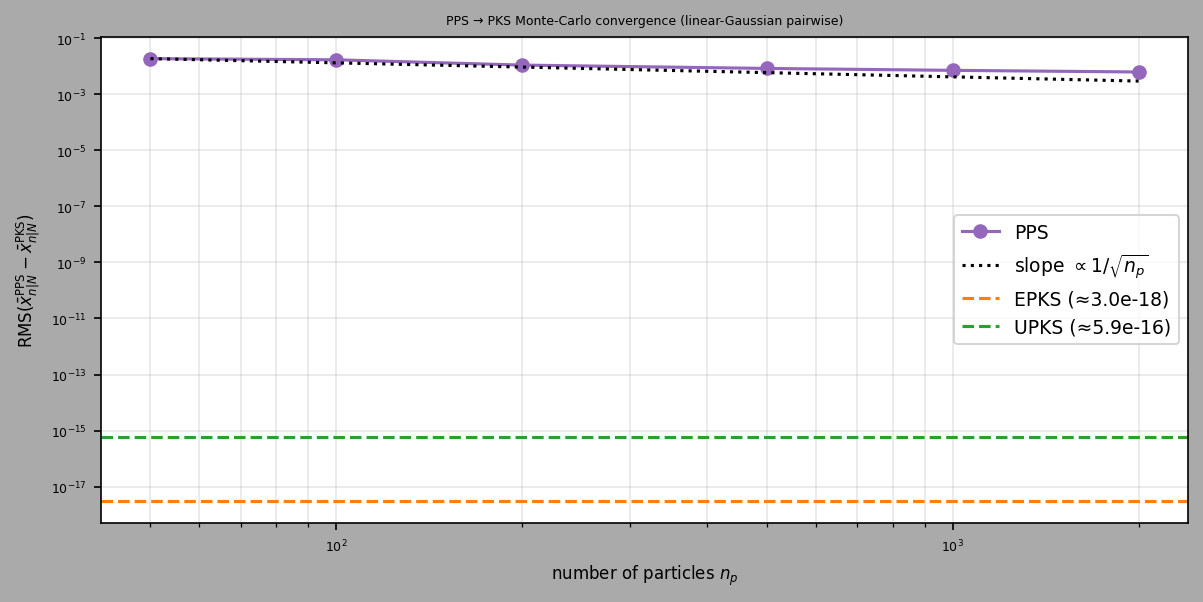

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
n_p_arr = np.array(n_p_list)
ax.loglog(n_p_arr, pps_rms, 'o-', color='tab:purple', label='PPS')
# Reference 1/sqrt(n_p) slope passing through the first point
ref = pps_rms[0] * np.sqrt(n_p_arr[0] / n_p_arr)
ax.loglog(n_p_arr, ref, 'k:', label=r'slope $\propto 1/\sqrt{n_p}$')
ax.axhline(rms_epks, color='tab:orange', ls='--', label=f'EPKS (≈{rms_epks:.1e})')
ax.axhline(rms_upks, color='tab:green',  ls='--', label=f'UPKS (≈{rms_upks:.1e})')
ax.set_xlabel(r'number of particles $n_p$')
ax.set_ylabel(r'RMS$(\bar{x}_{n|N}^{\mathrm{PPS}} - \bar{x}_{n|N}^{\mathrm{PKS}})$')
ax.grid(which='both', alpha=0.3); ax.legend(fontsize=9)
ax.set_title('PPS → PKS Monte-Carlo convergence (linear-Gaussian pairwise)')
fig.tight_layout()
plt.show()


The **~14-orders-of-magnitude separation** between PPS (Monte-Carlo error) and EPKS / UPKS (machine precision) is striking and is the central message of this section: on linear-Gaussian models, **PKS is the obvious choice**. PPS only earns its keep on models where the Kalman family cannot apply (genuinely non-gaussian posteriors, multi-modal distributions, hard state constraints).


## 6. Joseph form — Kalman-family numerical safeguard

The four Kalman smoothers expose a `joseph=True` flag selecting an explicitly symmetric / PSD-preserving form of the covariance update:

$$P^{xx}_{n|N} = \begin{pmatrix} I_p & -G_n \end{pmatrix} \Omega_n \begin{pmatrix} I_p \\ -G_n^\top \end{pmatrix} + G_n^x\, P^{xx}_{n+1|N}\, (G_n^x)^\top.$$

Mathematically equivalent to the standard form at the optimal gain, but **more numerically robust** when matrices are ill-conditioned (relevant for the non-linear smoothers).


In [13]:
param = make_param_nonlinear('model_x2_y1_pairwise')

epks_std = NonLinear_EPKS(param, sKey=SEED, joseph=False)
epks_jos = NonLinear_EPKS(param, sKey=SEED, joseph=True)
res_std = epks_std.process_N_data_smoother(N=150)
res_jos = epks_jos.process_N_data_smoother(N=150)

diff_mean = max(np.max(np.abs(a[5] - b[5])) for a, b in zip(res_std, res_jos))
diff_cov  = max(np.max(np.abs(r1['PXXkp1_smooth'] - r2['PXXkp1_smooth']))
                for r1, r2 in zip(epks_std.history, epks_jos.history))
print(f'Standard vs Joseph form — EPKS on model_x2_y1_pairwise:')
print(f'  max | X_std - X_jos | = {diff_mean:.2e}  (~ machine precision)')
print(f'  max | P_std - P_jos | = {diff_cov:.2e}   (~ machine precision)')


Standard vs Joseph form — EPKS on model_x2_y1_pairwise:
  max | X_std - X_jos | = 0.00e+00  (~ machine precision)
  max | P_std - P_jos | = 3.05e-16   (~ machine precision)


On well-conditioned cases the two forms agree to ~`1e-15` — they're algebraically the same thing. The Joseph form earns its keep when:

- the per-step sigma-point covariance loses PSD by `1e-10` floating-point drift,
- the model is on the edge of stability (eigenvalues of `A` close to 1),
- you're running 32-bit float instead of 64-bit.

Note: **PPS has no Joseph form** — particle smoothers reweight rather than apply a gain, so the PSD safeguard takes the form of log-sum-exp normalisation + degenerate-uniform fallback (see Section 4 above).


## 7. Which smoother for which scenario?

| Scenario | Recommended smoother | Why |
|---|---|---|
| Linear pairwise gaussian | **PKS** | exact, cheapest, no hyperparameters |
| Non-linear pairwise, mild curvature | **EPKS** | cheapest non-linear, Jacobian once per step |
| Non-linear pairwise, strong curvature | **UPKS** | unscented transform captures 2nd-order moments |
| Classical (Markov in X alone) | **UKS** | only one of the family that applies |
| Non-gaussian or multi-modal posterior | **PPS** | the only non-gaussian smoother in this family |

For a quantitative side-by-side comparison on identical trajectories, see Section 7 of the LaTeX report and the standalone reproducibility script `Report/NonLinearSmoothingReport/Figures/generate_comparison.py`.


## 8. Going Further

| Task | How |
|------|-----|
| Get the smoothed covariance trajectory | `[r['PXXkp1_smooth'] for r in smoother.history]` |
| Inspect the smoothing gain | `[r['Gk_smooth'] for r in smoother.history]` (Kalman family) |
| Inspect the smoothed particle weights | `[r['w_smooth'] for r in pps.history]` (PPS only) |
| Switch sigma-point set (UPKS / UKS) | `NonLinear_UPKS(param, sigmaSet='lerner2002', ...)` (also `cpkf`, `ito2000`) |
| Toggle Joseph form (Kalman family) | `NonLinear_EPKS(param, joseph=True)` |
| Run on saved CSV data | pass `data_generator=` to `process_N_data_smoother(...)` |
| Reproduce report Section 7 figures | `python Report/NonLinearSmoothingReport/Figures/generate_comparison.py` |
| Read the math derivations | `Report/NonLinearSmoothingReport/main.pdf`, Sections 2–7 |

See also: tutorials 01–06 for the forward filters, and tutorial 04 for the particle filter on which the PPS is built.
